In [1]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

import xgboost as xgb
from tensorflow import keras
from tensorflow.keras import layers, callbacks

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

RANDOM_STATE = 42

Load data

In [2]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [4]:
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")

print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Target distribution

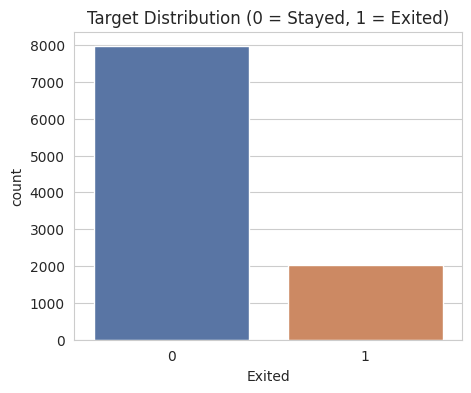

Churn rate: 20.37%  -> dataset is imbalanced


In [8]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Exited", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Target Distribution (0 = Stayed, 1 = Exited)")
plt.show()

churn_rate = df["Exited"].mean() * 100
print(f"Churn rate: {churn_rate:.2f}%  -> dataset is imbalanced")

Numeric feature distributions

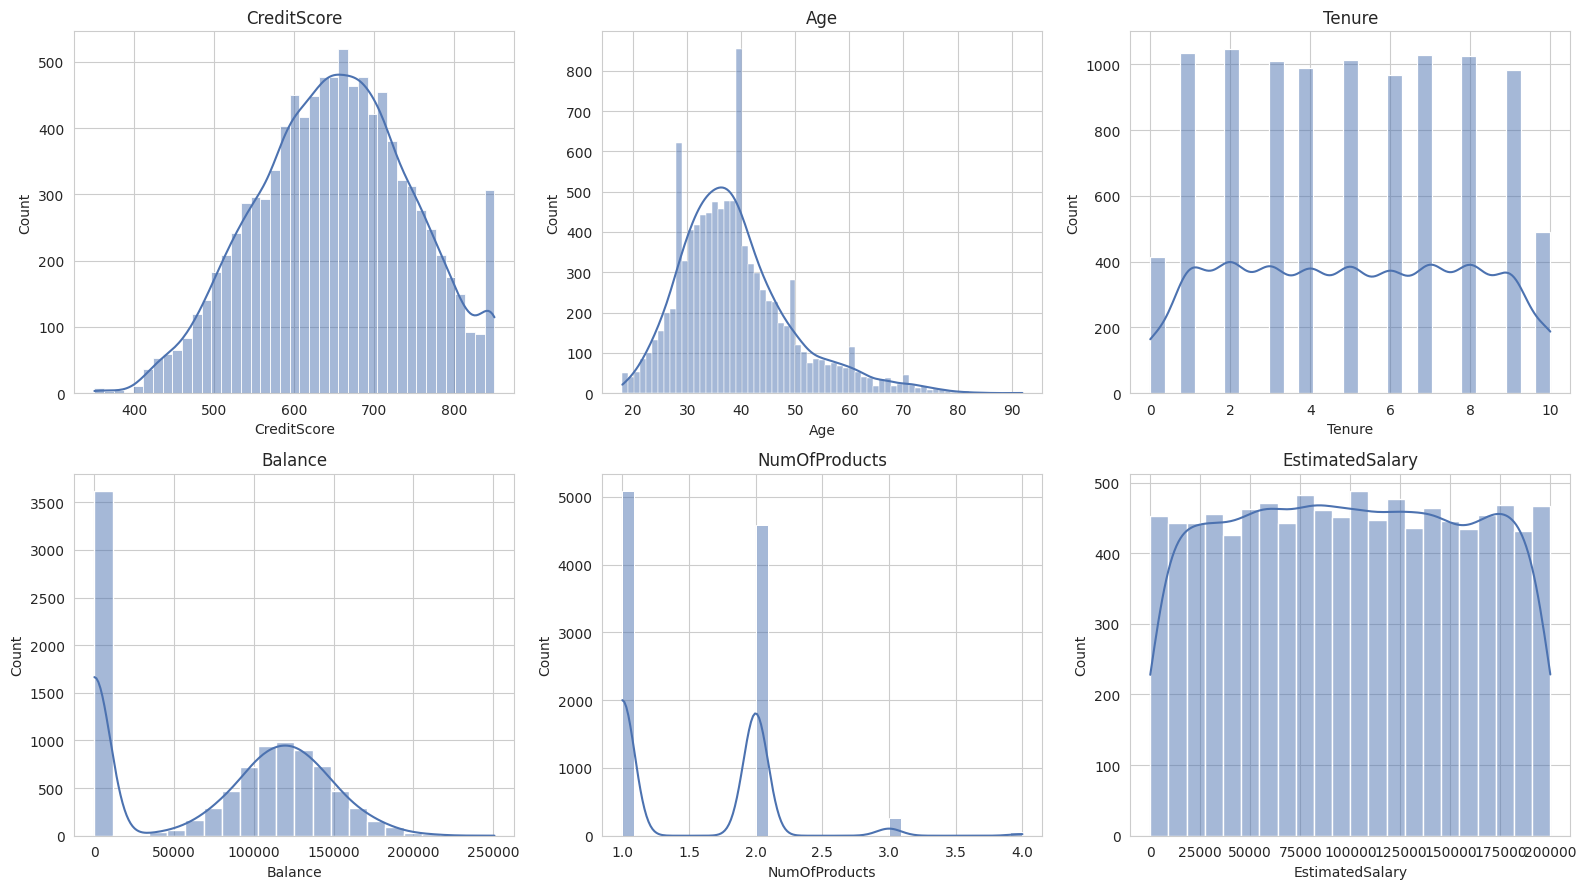

In [9]:
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance",
                 "NumOfProducts", "EstimatedSalary"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Numeric features vs churn

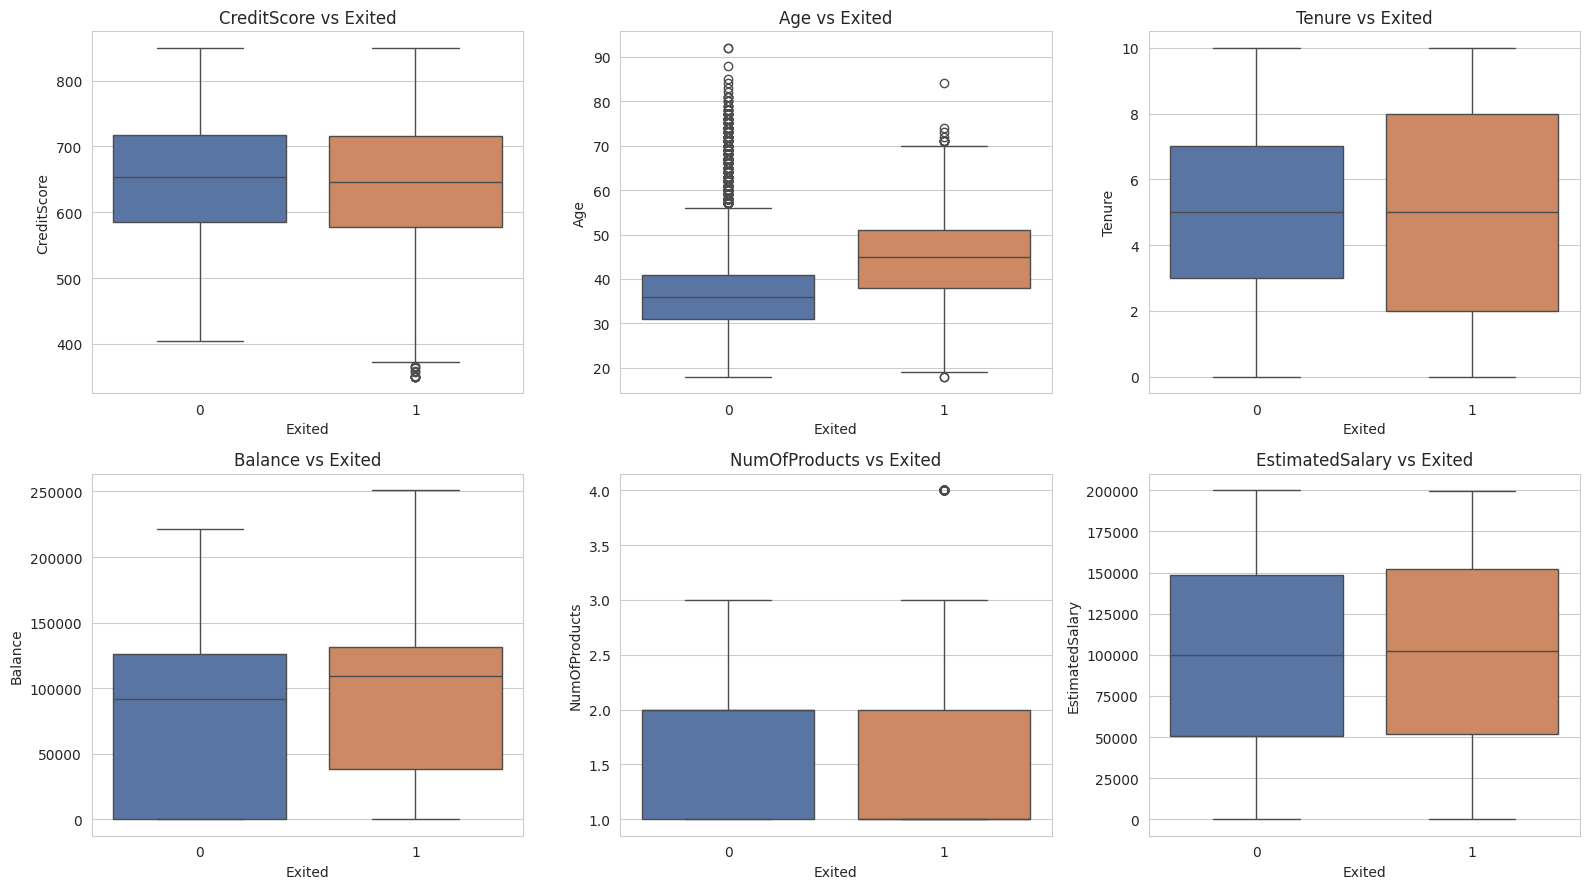

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(x="Exited", y=col, data=df, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_title(f"{col} vs Exited")
plt.tight_layout()
plt.show()

Categorical features vs churn

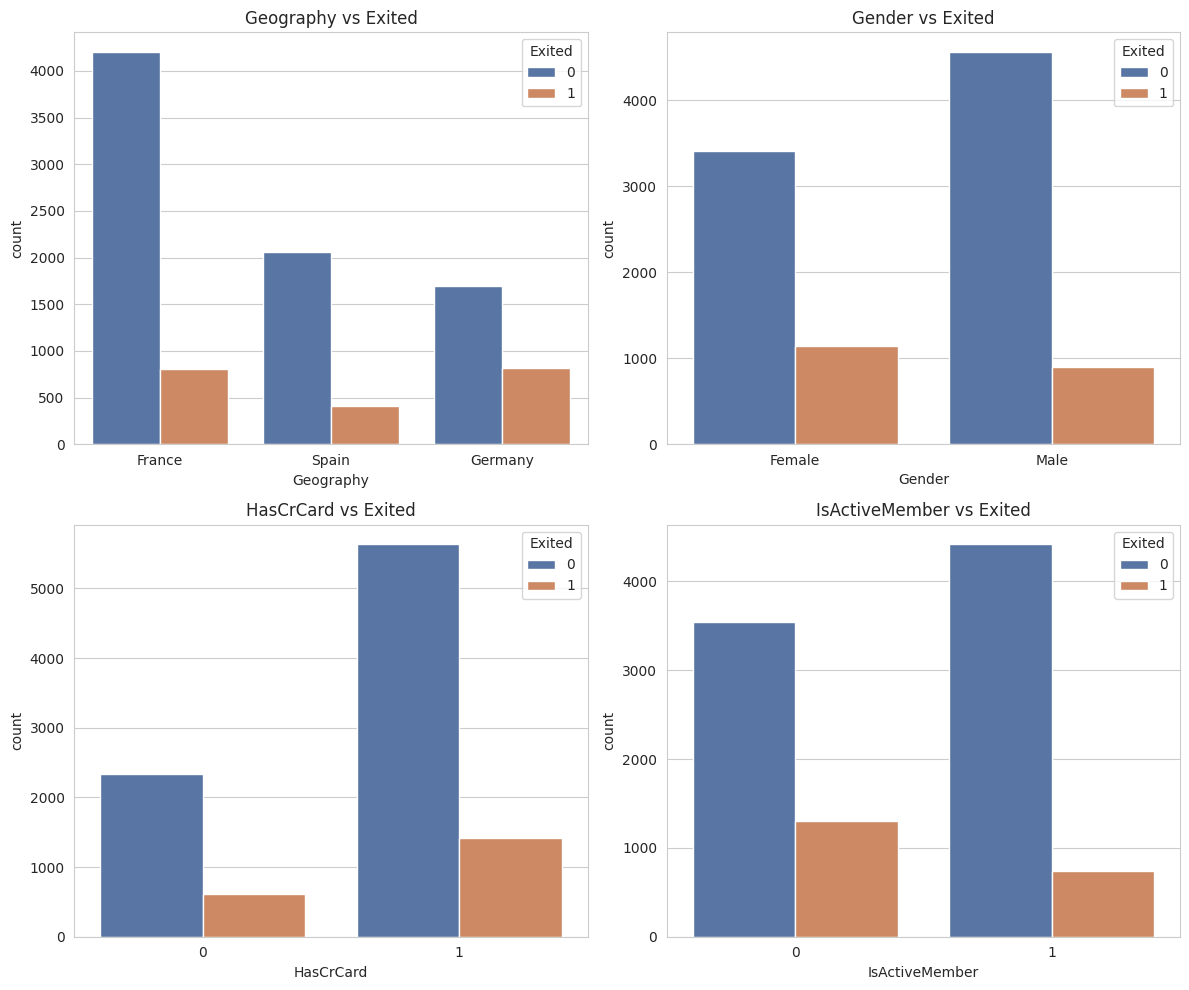

In [11]:
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(x=col, hue="Exited", data=df, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_title(f"{col} vs Exited")
plt.tight_layout()
plt.show()

Correlation Heatmap

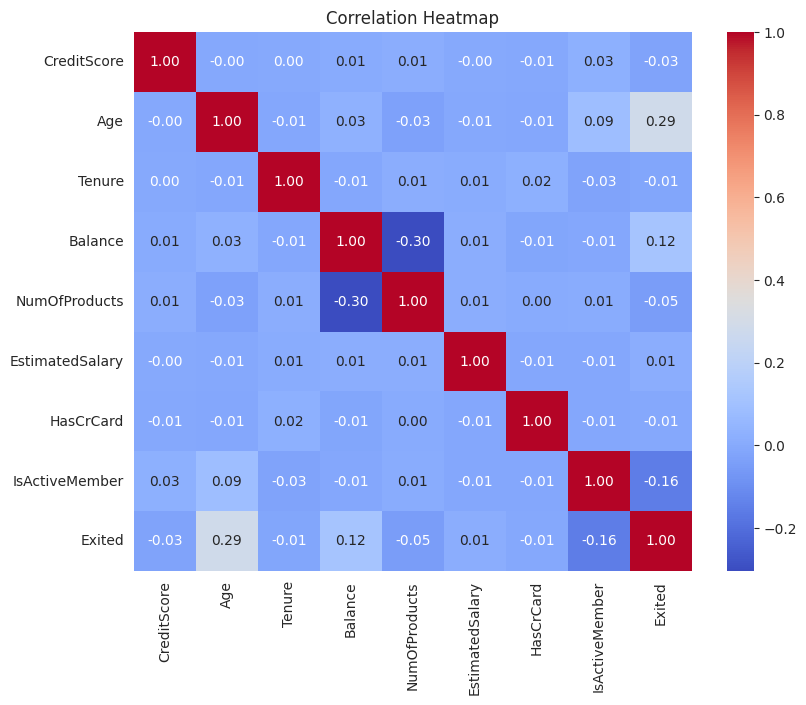

In [12]:
plt.figure(figsize=(9, 7))
corr_cols = numeric_cols + ["HasCrCard", "IsActiveMember", "Exited"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Preprocessing

In [13]:
data = df.copy()

# Drop identifier columns
data = data.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Encode Gender
data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})

# One-hot encode Geography
data = pd.get_dummies(data, columns=["Geography"], drop_first=True)
dummy_cols = [c for c in data.columns if c.startswith("Geography_")]
data[dummy_cols] = data[dummy_cols].astype(int)

data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


Train / Test Split and Feature scaling

In [14]:
X = data.drop(columns=["Exited"])
y = data["Exited"]

feature_columns = X.columns.tolist()
print("Final feature columns:", feature_columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale (fit on train only, to avoid leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler + column order for future inference
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_columns, "columns.pkl")

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Final feature columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
Train shape: (8000, 11), Test shape: (2000, 11)


Model 01 - XGBoost

In [15]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_pred_proba >= 0.5).astype(int)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print(f"XGBoost ROC-AUC : {xgb_auc:.4f}")
print("\n", classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.8115
XGBoost ROC-AUC : 0.8594

               precision    recall  f1-score   support

           0       0.92      0.83      0.88      1593
           1       0.53      0.72      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



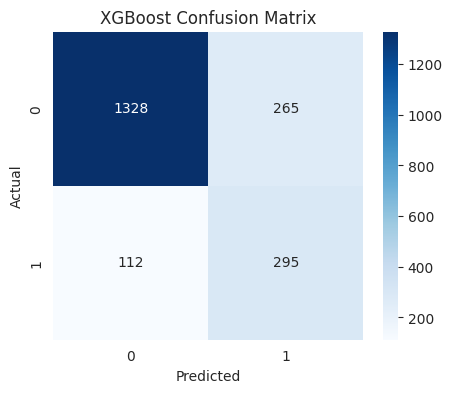

In [16]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model 02 - Artificial Neural Network

In [17]:
n_features = X_train_scaled.shape[1]

ann_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=15,
    restore_best_weights=True,
)

class_weight = {0: 1.0, 1: float(scale_pos_weight)}

history = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=0,
)

print(f"Training stopped after {len(history.history['loss'])} epochs")

Training stopped after 73 epochs


In [ ]:
ann_pred_proba = ann_model.predict(X_test_scaled, verbose=0).ravel()
ann_pred = (ann_pred_proba >= 0.5).astype(int)

ann_acc = accuracy_score(y_test, ann_pred)
ann_auc = roc_auc_score(y_test, ann_pred_proba)

print(f"ANN Accuracy: {ann_acc:.4f}")
print(f"ANN ROC-AUC : {ann_auc:.4f}")
print("\n", classification_report(y_test, ann_pred))

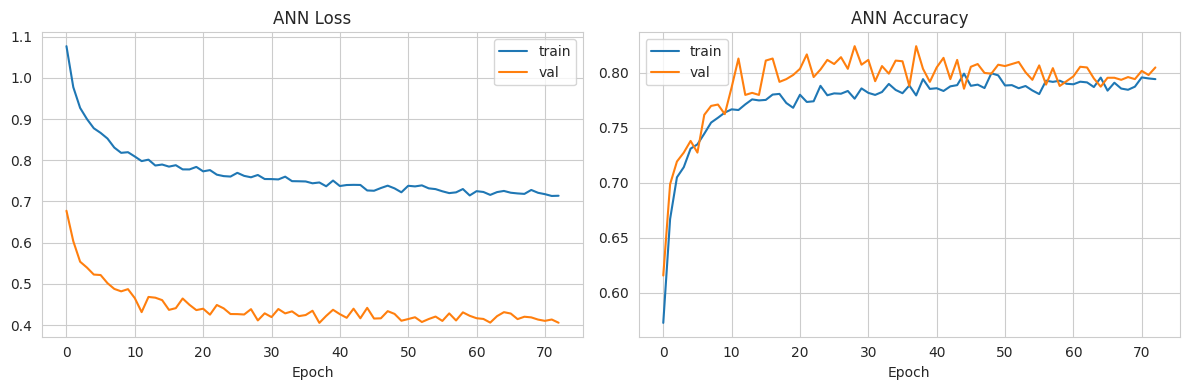

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("ANN Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("ANN Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


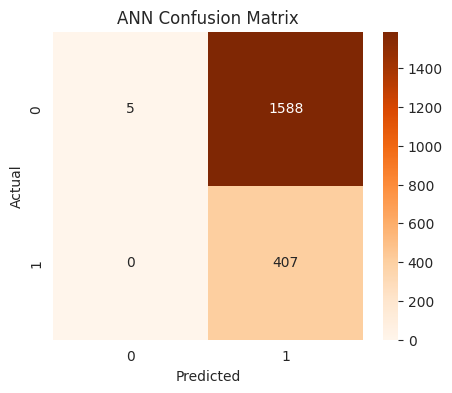

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Make predictions
ann_pred_prob = ann_model.predict(X_test)

# Convert probabilities to 0/1
ann_pred = (ann_pred_prob > 0.5).astype(int).ravel()

# Confusion Matrix
plt.figure(figsize=(5, 4))

sns.heatmap(
    confusion_matrix(y_test, ann_pred),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save the trained ANN model
ann_model.save("ann_model.keras")

Model Comparison

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


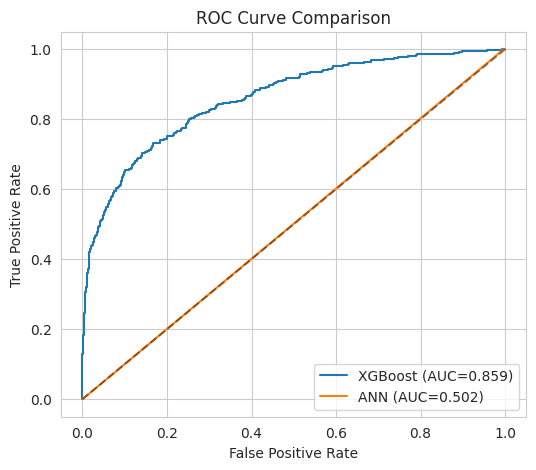

,Model,Accuracy,ROC-AUC
0,XGBoost,0.8115,0.859433
1,ANN,0.2060,0.501569


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# ANN predictions
# =========================

# Get probability predictions from ANN
ann_pred_proba = ann_model.predict(X_test).ravel()

# Convert probabilities to 0/1 predictions
ann_pred = (ann_pred_proba >= 0.5).astype(int)

# =========================
# ANN metrics
# =========================

ann_auc = roc_auc_score(y_test, ann_pred_proba)
ann_acc = (np.array(y_test) == ann_pred).mean()

# =========================
# XGBoost ROC
# =========================

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)

# =========================
# ANN ROC
# =========================

fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_pred_proba)

# =========================
# Plot ROC curves
# =========================

plt.figure(figsize=(6, 5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC={xgb_auc:.3f})"
)

plt.plot(
    fpr_ann,
    tpr_ann,
    label=f"ANN (AUC={ann_auc:.3f})"
)

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# Summary
# =========================

summary = pd.DataFrame({
    "Model": ["XGBoost", "ANN"],
    "Accuracy": [xgb_acc, ann_acc],
    "ROC-AUC": [xgb_auc, ann_auc],
})

summary

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, roc_auc_score

# Reproducibility
tf.random.set_seed(42)

# Build improved ANN
ann_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [26]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=15,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [27]:
history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7683 - auc: 0.5385 - loss: 0.5655 - val_accuracy: 0.7987 - val_auc: 0.5645 - val_loss: 0.5199 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7842 - auc: 0.5507 - loss: 0.5325 - val_accuracy: 0.8000 - val_auc: 0.5724 - val_loss: 0.5098 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7902 - auc: 0.5388 - loss: 0.5295 - val_accuracy: 0.8000 - val_auc: 0.5857 - val_loss: 0.4988 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7944 - auc: 0.5507 - loss: 0.5177 - val_accuracy: 0.8000 - val_auc: 0.5872 - val_loss: 0.4969 - learning_rate: 0.0010
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - auc: 0.5613 - loss: 0.5123 - val_accuracy: 0.8000 - val_auc: 0.5864 - val_loss: 0.4965 - learning_rate: 0.0010
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7952 - 

In [28]:
# Probability predictions
ann_pred_proba = ann_model.predict(X_test).ravel()

# Class predictions
ann_pred = (ann_pred_proba >= 0.5).astype(int)

# Metrics
ann_acc = accuracy_score(y_test, ann_pred)
ann_auc = roc_auc_score(y_test, ann_pred_proba)

print("ANN Accuracy:", ann_acc)
print("ANN ROC-AUC:", ann_auc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
ANN Accuracy: 0.7965
ANN ROC-AUC: 0.5558316405774033


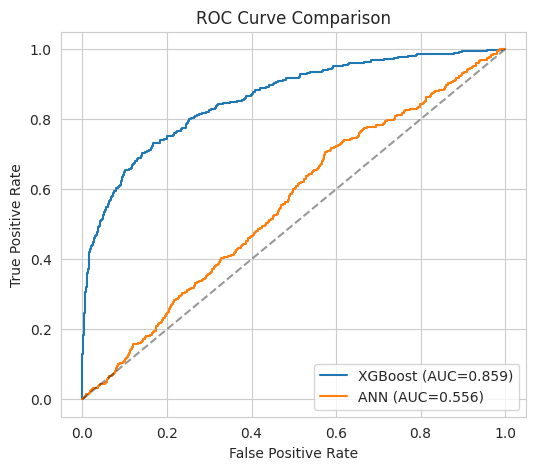

In [29]:
fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_pred_proba)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC={xgb_auc:.3f})"
)

plt.plot(
    fpr_ann,
    tpr_ann,
    label=f"ANN (AUC={ann_auc:.3f})"
)

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


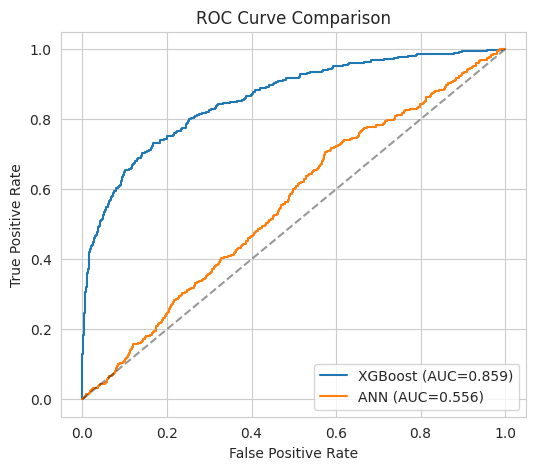

,Model,Accuracy,ROC-AUC
0,XGBoost,0.8115,0.859433
1,ANN,0.7965,0.555832


In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# ANN predictions
# =========================

# Get probability predictions from ANN
ann_pred_proba = ann_model.predict(X_test).ravel()

# Convert probabilities to 0/1 predictions
ann_pred = (ann_pred_proba >= 0.5).astype(int)

# =========================
# ANN metrics
# =========================

ann_auc = roc_auc_score(y_test, ann_pred_proba)
ann_acc = (np.array(y_test) == ann_pred).mean()

# =========================
# XGBoost ROC
# =========================

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)

# =========================
# ANN ROC
# =========================

fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_pred_proba)

# =========================
# Plot ROC curves
# =========================

plt.figure(figsize=(6, 5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC={xgb_auc:.3f})"
)

plt.plot(
    fpr_ann,
    tpr_ann,
    label=f"ANN (AUC={ann_auc:.3f})"
)

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# Summary
# =========================

summary = pd.DataFrame({
    "Model": ["XGBoost", "ANN"],
    "Accuracy": [xgb_acc, ann_acc],
    "ROC-AUC": [xgb_auc, ann_auc],
})

summary